### Downside


In [3]:
import pandas as pd
import edhec_risk_kit as erk

%load_ext autoreload
%autoreload 2
%matplotlib inline

pd.options.display.float_format = "{:.4f}".format

In [4]:
hfi = erk.get_hfi_returns()

c:\Users\beall\OneDrive\Documents\Repos\finance-classes\edhec\01 Intro to Portfolio Construction and Analysis\Mod-01\edhec_risk_kit.py:36: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  hfi = pd.read_csv(


### Semideviation


In [5]:
hfi.std(ddof=0)

Convertible Arbitrage    0.0165
CTA Global               0.0233
Distressed Securities    0.0170
Emerging Markets         0.0325
Equity Market Neutral    0.0081
Event Driven             0.0167
Fixed Income Arbitrage   0.0115
Global Macro             0.0147
Long/Short Equity        0.0199
Merger Arbitrage         0.0096
Relative Value           0.0115
Short Selling            0.0477
Funds Of Funds           0.0155
dtype: float64

In [6]:
hfi[hfi < 0].std(ddof=0)

Convertible Arbitrage    0.0195
CTA Global               0.0124
Distressed Securities    0.0152
Emerging Markets         0.0280
Equity Market Neutral    0.0096
Event Driven             0.0154
Fixed Income Arbitrage   0.0178
Global Macro             0.0066
Long/Short Equity        0.0141
Merger Arbitrage         0.0089
Relative Value           0.0122
Short Selling            0.0273
Funds Of Funds           0.0121
dtype: float64

In [7]:
hfi[hfi < 0].head()

,Convertible Arbitrage,CTA Global,Distressed Securities,Emerging Markets,Equity Market Neutral,Event Driven,Fixed Income Arbitrage,Global Macro,Long/Short Equity,Merger Arbitrage,Relative Value,Short Selling,Funds Of Funds
date,,,,,,,,,,,,,
1997-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0166,NaN
1997-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0006,NaN,NaN,NaN,NaN
1997-03-31,NaN,-0.0021,-0.0012,-0.0120,NaN,-0.0023,NaN,-0.0119,-0.0084,NaN,NaN,NaN,-0.0077
1997-04-30,NaN,-0.0170,NaN,NaN,NaN,-0.0005,NaN,NaN,NaN,-0.0001,NaN,-0.0129,NaN
1997-05-31,NaN,-0.0015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0737,NaN


In [8]:
erk.semideviation_0(hfi)

Convertible Arbitrage    0.0195
CTA Global               0.0124
Distressed Securities    0.0152
Emerging Markets         0.0280
Equity Market Neutral    0.0096
Event Driven             0.0154
Fixed Income Arbitrage   0.0178
Global Macro             0.0066
Long/Short Equity        0.0141
Merger Arbitrage         0.0089
Relative Value           0.0122
Short Selling            0.0273
Funds Of Funds           0.0121
dtype: float64

### VaR and CVaR

- Historic VaR
- Parametric VaR - Gaussian
- Modified Cornish-Fisher VaR


In [9]:
import numpy as np

In [10]:
np.percentile(hfi, 5, axis=0)

array([-0.01576, -0.03169, -0.01966, -0.04247, -0.00814, -0.02535,
       -0.00787, -0.01499, -0.02598, -0.01047, -0.01174, -0.06783,
       -0.02047])

In [11]:
hfi.quantile(0.05)

Convertible Arbitrage    -0.0158
CTA Global               -0.0317
Distressed Securities    -0.0197
Emerging Markets         -0.0425
Equity Market Neutral    -0.0081
Event Driven             -0.0253
Fixed Income Arbitrage   -0.0079
Global Macro             -0.0150
Long/Short Equity        -0.0260
Merger Arbitrage         -0.0105
Relative Value           -0.0117
Short Selling            -0.0678
Funds Of Funds           -0.0205
Name: 0.05, dtype: float64

In [12]:
hfi.quantile(0.95)

Convertible Arbitrage    0.0243
CTA Global               0.0435
Distressed Securities    0.0311
Emerging Markets         0.0526
Equity Market Neutral    0.0165
Event Driven             0.0297
Fixed Income Arbitrage   0.0163
Global Macro             0.0293
Long/Short Equity        0.0349
Merger Arbitrage         0.0197
Relative Value           0.0198
Short Selling            0.0752
Funds Of Funds           0.0274
Name: 0.95, dtype: float64

In [13]:
pd.Series(np.percentile(hfi, 5, axis=0), index=hfi.columns)

Convertible Arbitrage    -0.0158
CTA Global               -0.0317
Distressed Securities    -0.0197
Emerging Markets         -0.0425
Equity Market Neutral    -0.0081
Event Driven             -0.0253
Fixed Income Arbitrage   -0.0079
Global Macro             -0.0150
Long/Short Equity        -0.0260
Merger Arbitrage         -0.0105
Relative Value           -0.0117
Short Selling            -0.0678
Funds Of Funds           -0.0205
dtype: float64

In [14]:
import numpy as np

erk.var_historic(hfi)

Convertible Arbitrage    0.0158
CTA Global               0.0317
Distressed Securities    0.0197
Emerging Markets         0.0425
Equity Market Neutral    0.0081
Event Driven             0.0253
Fixed Income Arbitrage   0.0079
Global Macro             0.0150
Long/Short Equity        0.0260
Merger Arbitrage         0.0105
Relative Value           0.0117
Short Selling            0.0678
Funds Of Funds           0.0205
dtype: float64

In [15]:
from scipy.stats import norm

In [16]:
z = norm.ppf(0.05)

In [17]:
z

np.float64(-1.6448536269514729)

In [18]:
-(hfi.mean() + z * hfi.std(ddof=0))

Convertible Arbitrage    0.0217
CTA Global               0.0342
Distressed Securities    0.0210
Emerging Markets         0.0472
Equity Market Neutral    0.0088
Event Driven             0.0211
Fixed Income Arbitrage   0.0146
Global Macro             0.0188
Long/Short Equity        0.0264
Merger Arbitrage         0.0104
Relative Value           0.0131
Short Selling            0.0801
Funds Of Funds           0.0213
dtype: float64

In [19]:
erk.var_gaussian(hfi)

Convertible Arbitrage    0.0217
CTA Global               0.0342
Distressed Securities    0.0210
Emerging Markets         0.0472
Equity Market Neutral    0.0088
Event Driven             0.0211
Fixed Income Arbitrage   0.0146
Global Macro             0.0188
Long/Short Equity        0.0264
Merger Arbitrage         0.0104
Relative Value           0.0131
Short Selling            0.0801
Funds Of Funds           0.0213
dtype: float64

In [20]:
var_list = [
    erk.var_historic(hfi),
    erk.var_gaussian(hfi),
    erk.var_gaussian(hfi, modified=True),
]
comparison = pd.DataFrame(
    var_list, index=["Historic", "Gaussian", "Cornish-Fisher"], columns=hfi.columns
)
comparison

,Convertible Arbitrage,CTA Global,Distressed Securities,Emerging Markets,Equity Market Neutral,Event Driven,Fixed Income Arbitrage,Global Macro,Long/Short Equity,Merger Arbitrage,Relative Value,Short Selling,Funds Of Funds
Historic,0.0158,0.0317,0.0197,0.0425,0.0081,0.0253,0.0079,0.0150,0.0260,0.0105,0.0117,0.0678,0.0205
Gaussian,0.0217,0.0342,0.0210,0.0472,0.0088,0.0211,0.0146,0.0188,0.0264,0.0104,0.0131,0.0801,0.0213
Cornish-Fisher,0.0252,0.0331,0.0251,0.0530,0.0107,0.0255,0.0179,0.0136,0.0279,0.0126,0.0162,0.0662,0.0216


<Axes: title={'center': 'EDHEC Hedge Fund Index: VaR Comparison'}>

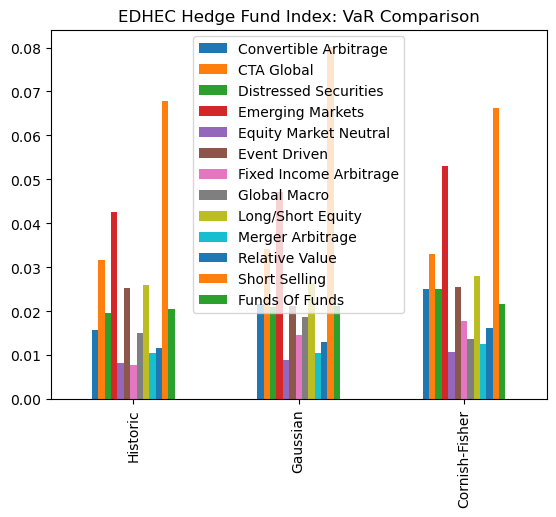

In [21]:
comparison.plot.bar(title="EDHEC Hedge Fund Index: VaR Comparison")

<Axes: title={'center': 'EDHEC Hedge Fund Index: VaR Comparison'}>

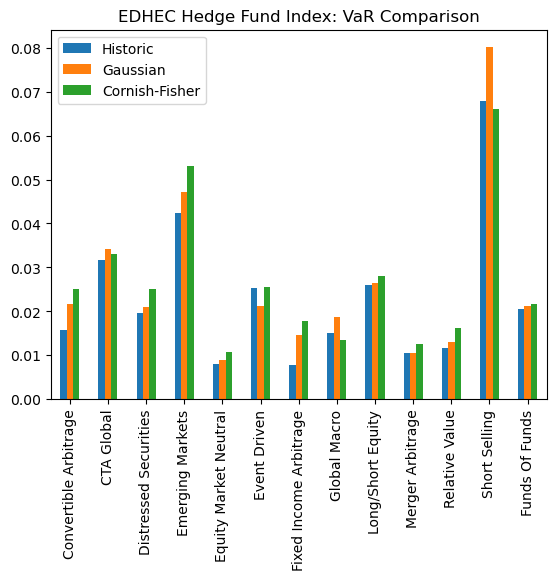

In [22]:
var_list = [
    erk.var_historic(hfi),
    erk.var_gaussian(hfi),
    erk.var_gaussian(hfi, modified=True),
]
comparisonEdhec = pd.concat(
    var_list, axis=1, keys=["Historic", "Gaussian", "Cornish-Fisher"]
)
comparisonEdhec.plot.bar(title="EDHEC Hedge Fund Index: VaR Comparison")

### BeyondVar aka CVaR


In [23]:
erk.cvar_historic(hfi).round(4)

Convertible Arbitrage    0.0365
CTA Global               0.0413
Distressed Securities    0.0364
Emerging Markets         0.0724
Equity Market Neutral    0.0169
Event Driven             0.0383
Fixed Income Arbitrage   0.0283
Global Macro             0.0206
Long/Short Equity        0.0419
Merger Arbitrage         0.0191
Relative Value           0.0246
Short Selling            0.0968
Funds Of Funds           0.0332
dtype: float64

In [24]:
level = 5
z = norm.ppf(level / 100)
z

np.float64(-1.6448536269514729)

In [25]:
erk.var_gaussian(hfi)

Convertible Arbitrage    0.0217
CTA Global               0.0342
Distressed Securities    0.0210
Emerging Markets         0.0472
Equity Market Neutral    0.0088
Event Driven             0.0211
Fixed Income Arbitrage   0.0146
Global Macro             0.0188
Long/Short Equity        0.0264
Merger Arbitrage         0.0104
Relative Value           0.0131
Short Selling            0.0801
Funds Of Funds           0.0213
dtype: float64